# Avaliação SSL centralizado (LFR) — DAGHAR / HAR

Notebook **somente de leitura/visualização**. Lê os caches gerados por
`scripts/ssl/downstream_eval.py` e `scripts/eval_transfer.py` e produz a
comparação **supervisionado (SL) vs auto-supervisionado (SSL)** ao longo dos
regimes de dados rotulados.

**Pipeline SSL avaliado**: para cada (encoder, fonte, semente) um *backbone* é
pré-treinado com **LFR** na fonte (sem rótulos) e depois avaliado na matriz de
transfer 7×6 (fontes = 6 datasets + `combined`; alvos = 6 datasets), em:

- **2 protocolos**: `linear` (readout, backbone congelado) e `finetune`
  (full finetuning, backbone descongelado);
- **4 regimes de dados rotulados** (`n_shots`): 1 / 10 / 100 amostras-por-classe
  e 100% (`full`).

Fontes de dados:
`results/ssl_lfr_eval_transfer.csv`
(`encoder, source, seed, protocol, n_shots, target, test_acc, test_f1_macro`) e
`results/supervised_eval_transfer.csv` (baseline SL, mesmos eixos).

Cenários de avaliação usados ao longo do notebook:

- **Especialista (in-domain)**: `source == target` — teto por domínio.
- **Generalista (combinado)**: `source == combined` — um único modelo p/ os 6 alvos.
- **Transfer out-domain**: `source ∈ datasets, source != target` — generalização cross-domínio.

Estrutura: **1.** setup · **2.** cargas · **3.** matrizes de transfer (protocol×regime)
· **4.** data-efficiency SL vs SSL · **5.** comparação direta @100% · **6.** barras por
cenário · **7.** Δ(SSL−SL) caso a caso por dataset · **8.** Δ do transfer fonte×alvo
· **9.** gap especialista × combinado × transfer · **10.** conclusões.

## 1. Setup

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
PROJECT_ROOT = None
while _p != _p.parent:
    if (_p / "minerva").is_dir() and (_p / "scripts").is_dir():
        PROJECT_ROOT = _p
        break
    _p = _p.parent
if PROJECT_ROOT is None:
    raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")

for p in (PROJECT_ROOT, PROJECT_ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /home/miguel.barreto/fed-har


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from common import DATASETS, COMBINED_DATASET_NAME

warnings.filterwarnings("ignore")
sns.set_context("notebook")

ENCODERS = ["resnetse5", "cnnpff", "rnn"]
ENCODER_PRETTY = {"resnetse5": "ResNet-SE-5", "cnnpff": "CNN-PFF", "rnn": "RNN (BiGRU)"}
COMBINED = COMBINED_DATASET_NAME
COMBINED_PRETTY = "Combinado (todos)"
TRANSFER_SOURCES = [COMBINED] + DATASETS
PROTOCOLS = ["linear", "finetune"]
PROTOCOL_PRETTY = {"linear": "Linear readout", "finetune": "Full finetuning"}

# Eixo de regimes de dados (posições equidistantes; rótulo "100%" para full).
SHOT_ORDER = ["1", "10", "100", "full"]
SHOT_LABELS = {"1": "1", "10": "10", "100": "100", "full": "100%"}

# Cores por método (SL vs os 2 protocolos SSL), colorblind-friendly.
METHOD_COLORS = {
    "SL":            "#0173B2",  # azul   — supervisionado (referência)
    "SSL-linear":    "#DE8F05",  # laranja — SSL linear readout
    "SSL-finetune":  "#029E73",  # verde  — SSL full finetuning
}
HEATMAP_CMAP = "mako"

RESULTS_DIR = PROJECT_ROOT / "results"
SSL_CACHE = RESULTS_DIR / "ssl_lfr_eval_transfer.csv"
SUP_CACHE = RESULTS_DIR / "supervised_eval_transfer.csv"
print("SSL cache:", SSL_CACHE)
print("SL  cache:", SUP_CACHE)

SSL cache: /home/miguel.barreto/fed-har/results/ssl_lfr_eval_transfer.csv
SL  cache: /home/miguel.barreto/fed-har/results/supervised_eval_transfer.csv


## 2. Cargas dos caches

Ambos os caches são apenas lidos. Para (re)gerar:

```bash
python scripts/ssl/pretrain_lfr.py        # 84 backbones LFR
python scripts/ssl/downstream_eval.py     # linear + finetune × 4 regimes
python scripts/eval_transfer.py --shots... # baseline SL nos regimes (ver notebook supervisionado)
```

In [3]:
SSL_COLS = ["encoder", "source", "seed", "protocol", "n_shots",
            "target", "test_acc", "test_f1_macro"]
SUP_COLS = ["encoder", "source", "seed", "n_shots", "target", "test_acc", "test_f1_macro"]


def _load(path, cols, backfill_shots=False):
    if not path.exists():
        print(f"[aviso] cache ausente: {path.name} — rode os scripts correspondentes.")
        return pd.DataFrame(columns=cols)
    df = pd.read_csv(path)
    if backfill_shots and "n_shots" not in df.columns:
        df["n_shots"] = "full"
    if "n_shots" in df.columns:
        df["n_shots"] = df["n_shots"].fillna("full").astype(str)
    for c in cols:
        if c not in df.columns:
            df[c] = pd.NA
    df["test_acc"] = pd.to_numeric(df["test_acc"], errors="coerce")
    df["test_f1_macro"] = pd.to_numeric(df["test_f1_macro"], errors="coerce")
    return df[cols]


ssl_df = _load(SSL_CACHE, SSL_COLS)
sup_df = _load(SUP_CACHE, SUP_COLS, backfill_shots=True)

if not ssl_df.empty:
    print(f"SSL: {len(ssl_df)} linhas | protocolos={sorted(ssl_df.protocol.unique())} "
          f"| regimes={sorted(ssl_df.n_shots.unique())}")
if not sup_df.empty:
    print(f"SL : {len(sup_df)} linhas | regimes={sorted(sup_df.n_shots.unique())}")
ssl_df.head()

SSL: 4032 linhas | protocolos=['finetune', 'linear'] | regimes=['1', '10', '100', 'full']
SL : 2016 linhas | regimes=['1', '10', '100', 'full']


,encoder,source,seed,protocol,n_shots,target,test_acc,test_f1_macro
0,cnnpff,KuHar,0,finetune,1,KuHar,0.414062,0.296856
1,cnnpff,KuHar,0,finetune,1,MotionSense,0.338867,0.254243
2,cnnpff,KuHar,0,finetune,1,RealWorld_thigh,0.334375,0.265902
3,cnnpff,KuHar,0,finetune,1,RealWorld_waist,0.389453,0.303089
4,cnnpff,KuHar,0,finetune,1,UCI,0.339062,0.222756


## 3. Matrizes de transfer 7×6 (por protocolo × regime)

Heatmaps `source → target` (linha = fonte do pré-treino/backbone, `combined` na
1ª linha; coluna = alvo). Agregado sobre os 3 encoders × seeds. A diagonal =
in-domain; o off-diagonal = transferência cross-domínio. Use `draw_ssl_heatmap`
para inspecionar qualquer combinação (protocolo, regime, encoder).

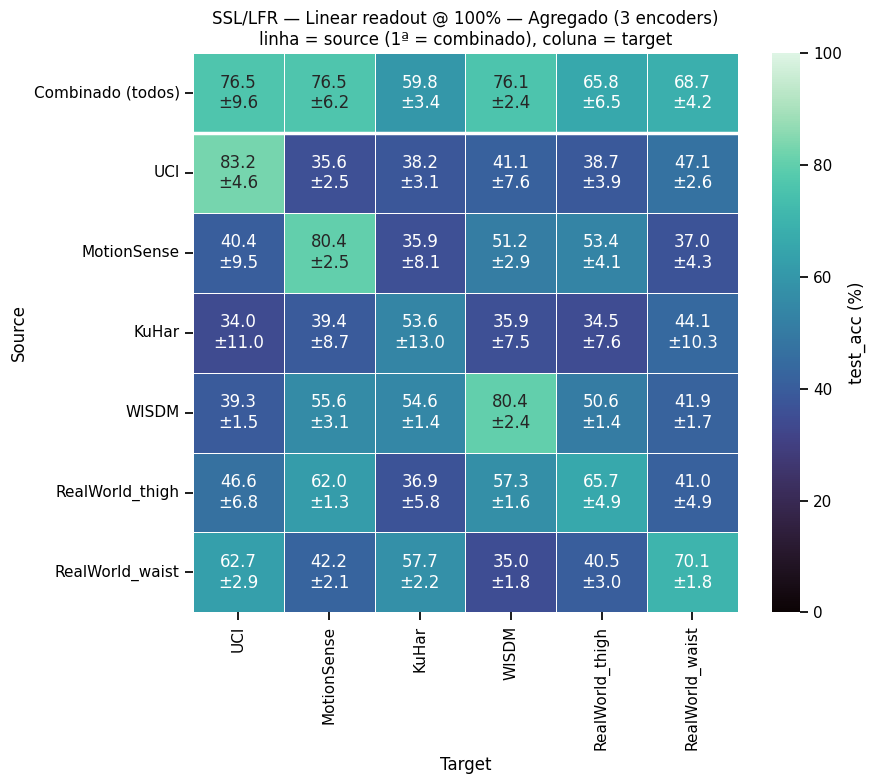

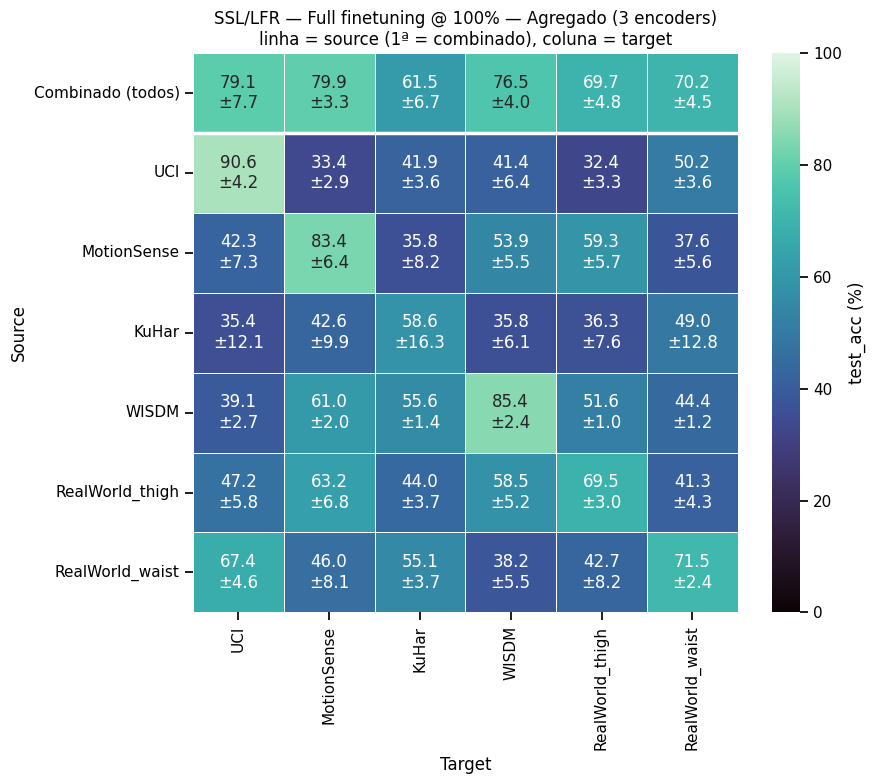

In [4]:
def _draw_transfer_heatmap(sub: pd.DataFrame, title: str):
    agg = sub.groupby(["source", "target"])["test_acc"].agg(["mean", "std"]).reset_index()
    mean_mat = agg.pivot(index="source", columns="target", values="mean").reindex(
        index=TRANSFER_SOURCES, columns=DATASETS).astype(float)
    std_mat = agg.pivot(index="source", columns="target", values="std").reindex(
        index=TRANSFER_SOURCES, columns=DATASETS).astype(float)
    annot = np.empty_like(mean_mat.values, dtype=object)
    for i in range(mean_mat.shape[0]):
        for j in range(mean_mat.shape[1]):
            m, s = mean_mat.values[i, j], std_mat.values[i, j]
            annot[i, j] = "" if pd.isna(m) else (f"{m*100:.1f}" if pd.isna(s) else f"{m*100:.1f}\n±{s*100:.1f}")
    mean_disp = mean_mat.rename(index={COMBINED: COMBINED_PRETTY})
    fig, ax = plt.subplots(figsize=(9, 8))
    sns.heatmap(mean_disp * 100, annot=annot, fmt="", cmap=HEATMAP_CMAP, vmin=0, vmax=100,
                cbar_kws={"label": "test_acc (%)"}, ax=ax, linewidths=0.5)
    ax.axhline(1, color="white", linewidth=2.5)
    ax.set_title(title); ax.set_xlabel("Target"); ax.set_ylabel("Source")
    plt.tight_layout(); plt.show()


def draw_ssl_heatmap(protocol: str, n_shots: str = "full", encoder=None):
    if ssl_df.empty:
        print("Sem dados SSL."); return
    sub = ssl_df[(ssl_df.protocol == protocol) & (ssl_df.n_shots.astype(str) == str(n_shots))]
    if encoder is not None:
        sub = sub[sub.encoder == encoder]
    if sub.empty:
        print(f"Sem dados para protocol={protocol}, n_shots={n_shots}, encoder={encoder}."); return
    enc_txt = ENCODER_PRETTY.get(encoder, "Agregado (3 encoders)")
    _draw_transfer_heatmap(
        sub, f"SSL/LFR — {PROTOCOL_PRETTY[protocol]} @ {SHOT_LABELS.get(str(n_shots), n_shots)} — {enc_txt}\n"
             "linha = source (1ª = combinado), coluna = target")


# Visões-chave @100%: linear vs finetune (agregado sobre encoders).
for _proto in PROTOCOLS:
    draw_ssl_heatmap(_proto, "full")

## 4. Data-efficiency — SL vs SSL ao longo dos regimes

O gráfico central do experimento: acurácia vs. nº de rótulos por classe no treino
downstream, comparando **supervisionado (SL)** contra **SSL linear** e
**SSL finetune**. Duas visões:

- **in-domain** (`source == target`): representa o teto por domínio.
- **transfer out-domain** (`source ∈ datasets, source ≠ target`): generalização
  cross-domínio.

**Hipótese central**: o SSL deve **superar** o SL nos regimes de poucos rótulos
(1/10-shot) e **empatar** com ele a 100% — evidenciando o ganho de eficiência de
dados do pré-treino auto-supervisionado.

>> In-domain:


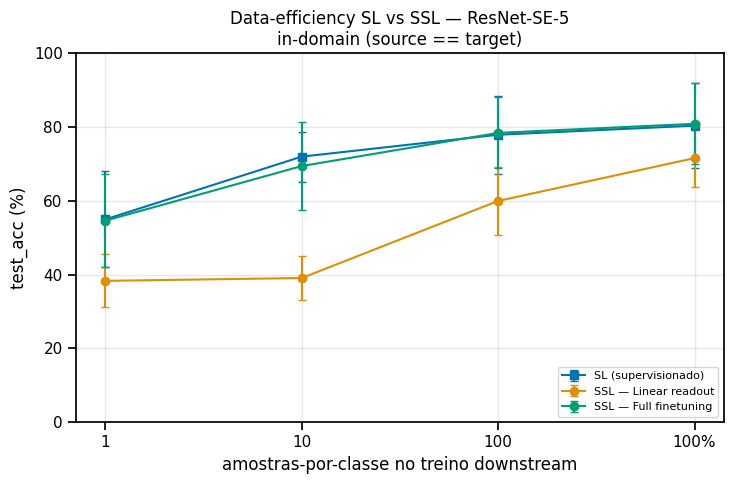

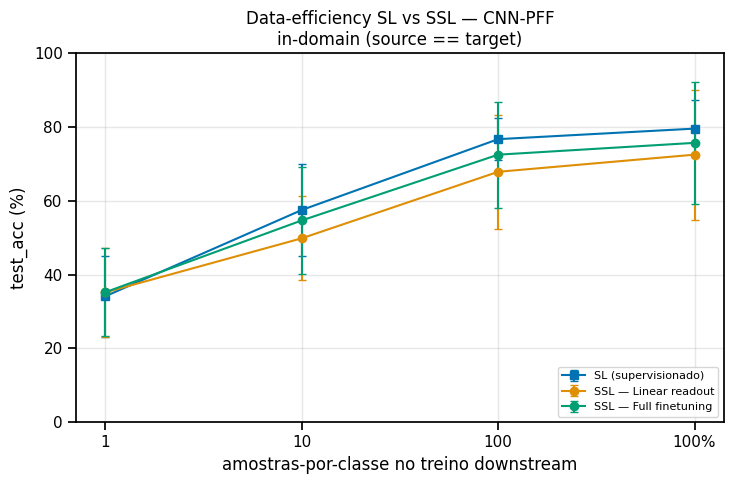

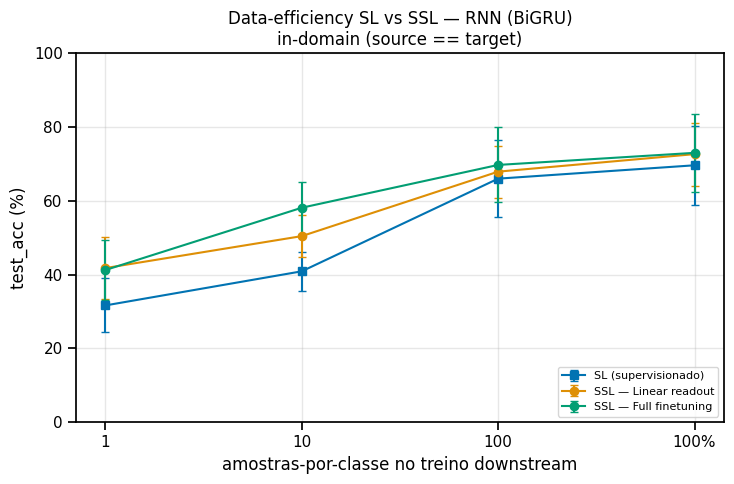

>> Transfer out-domain:


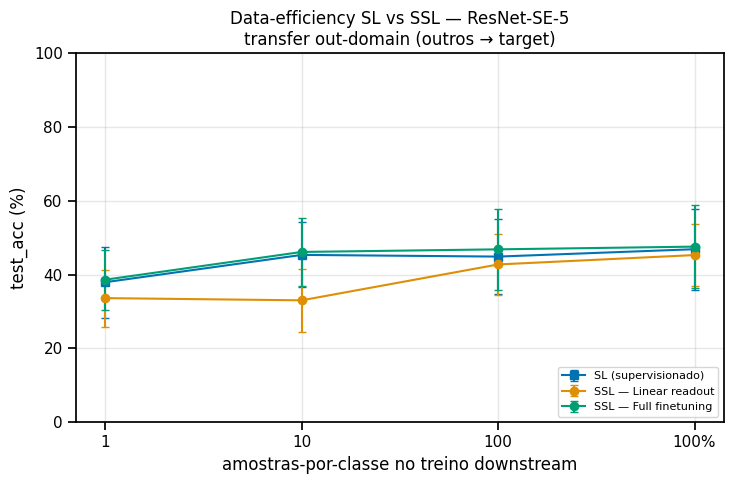

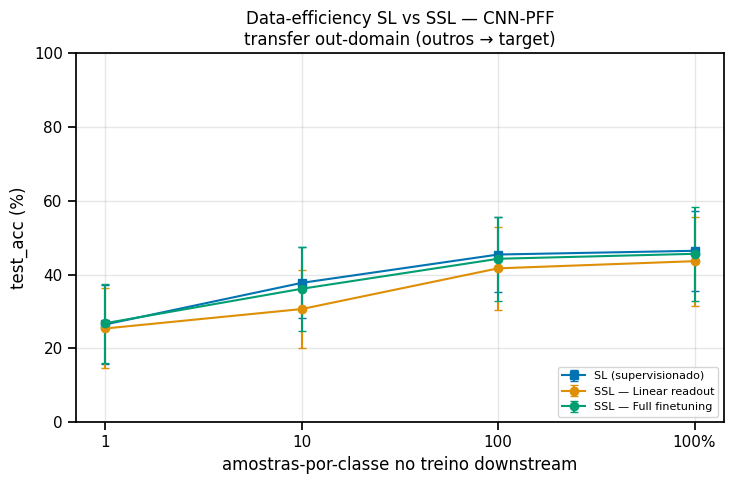

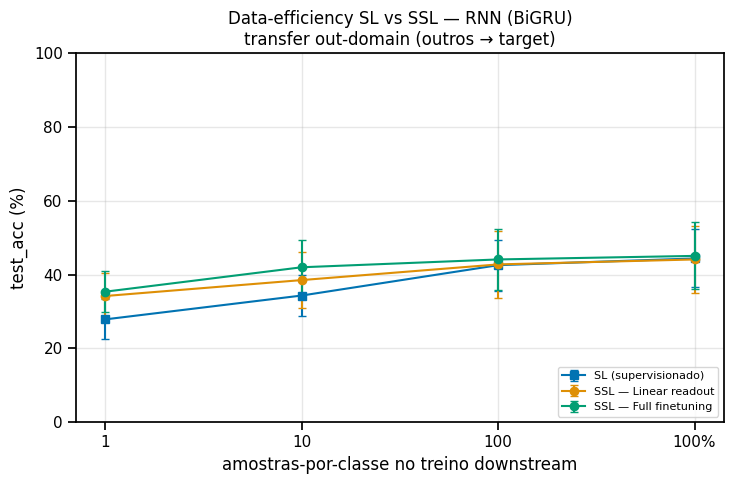

In [5]:
def _curve(df, encoder, view):
    """(shots, mean, std) de test_acc por regime. `view` in {'in','out'}."""
    d = df[df.encoder == encoder] if encoder else df
    if "source" in d.columns:
        if view == "in":
            d = d[d.source == d.target]
        else:  # out-domain transfer (exclui o combinado e o próprio domínio)
            d = d[(d.source.isin(DATASETS)) & (d.source != d.target)]
    xs, ms, ss = [], [], []
    for i, shots in enumerate(SHOT_ORDER):
        v = d[d.n_shots.astype(str) == shots]["test_acc"].dropna()
        if v.empty:
            continue
        xs.append(i); ms.append(v.mean() * 100); ss.append(v.std() * 100)
    return xs, ms, ss


def plot_data_efficiency(view="in", encoders=None):
    if ssl_df.empty and sup_df.empty:
        print("Sem dados."); return
    encoders = encoders or ENCODERS
    title_view = "in-domain (source == target)" if view == "in" else "transfer out-domain (outros → target)"
    for encoder in encoders:
        fig, ax = plt.subplots(figsize=(7.5, 5))
        drew = False
        # SL (baseline supervisionado)
        if not sup_df.empty:
            xs, m, s = _curve(sup_df, encoder, view)
            if xs:
                ax.errorbar(xs, m, yerr=s, marker="s", capsize=3,
                            color=METHOD_COLORS["SL"], label="SL (supervisionado)"); drew = True
        # SSL linear e finetune
        for proto, key in [("linear", "SSL-linear"), ("finetune", "SSL-finetune")]:
            if ssl_df.empty:
                continue
            xs, m, s = _curve(ssl_df[ssl_df.protocol == proto], encoder, view)
            if xs:
                ax.errorbar(xs, m, yerr=s, marker="o", capsize=3,
                            color=METHOD_COLORS[key], label=f"SSL — {PROTOCOL_PRETTY[proto]}"); drew = True
        if not drew:
            plt.close(fig); print(f"[{encoder}] sem dados."); continue
        ax.set_xticks(range(len(SHOT_ORDER)))
        ax.set_xticklabels([SHOT_LABELS[s] for s in SHOT_ORDER])
        ax.set_xlabel("amostras-por-classe no treino downstream")
        ax.set_ylabel("test_acc (%)"); ax.set_ylim(0, 100)
        ax.set_title(f"Data-efficiency SL vs SSL — {ENCODER_PRETTY[encoder]}\n{title_view}")
        ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right")
        plt.tight_layout(); plt.show()


print(">> In-domain:")
plot_data_efficiency(view="in")
print(">> Transfer out-domain:")
plot_data_efficiency(view="out")

## 5. Comparação direta @ 100% dos dados (SSL finetune vs SL)

`finetune @ full` parte de uma inicialização SSL; o baseline SL parte de
inicialização aleatória. A tabela resume a acurácia in-domain (média das seeds)
por encoder e o delta SSL−SL em pontos percentuais.

In [6]:
def compare_full():
    if ssl_df.empty or sup_df.empty:
        print("Precisa dos dois caches (SSL e SL) no regime 'full'."); return
    rows = []
    for encoder in ENCODERS:
        sl = sup_df[(sup_df.encoder == encoder) & (sup_df.n_shots.astype(str) == "full")
                    & (sup_df.source == sup_df.target)]["test_acc"].dropna()
        ss = ssl_df[(ssl_df.encoder == encoder) & (ssl_df.protocol == "finetune")
                    & (ssl_df.n_shots.astype(str) == "full")
                    & (ssl_df.source == ssl_df.target)]["test_acc"].dropna()
        if sl.empty and ss.empty:
            continue
        rows.append({
            "Encoder": ENCODER_PRETTY[encoder],
            "SL @100% (in-dist) %": sl.mean() * 100 if not sl.empty else np.nan,
            "SSL finetune @100% %": ss.mean() * 100 if not ss.empty else np.nan,
            "Δ SSL−SL (pp)": (ss.mean() - sl.mean()) * 100 if (not sl.empty and not ss.empty) else np.nan,
        })
    if not rows:
        print("Sem dados no regime full."); return
    display(pd.DataFrame(rows).set_index("Encoder").round(2))


compare_full()

,SL @100% (in-dist) %,SSL finetune @100% %,Δ SSL−SL (pp)
Encoder,,,
ResNet-SE-5,80.36,80.86,0.50
CNN-PFF,79.55,75.69,-3.86
RNN (BiGRU),69.61,72.99,3.37


## 6. Barras por cenário — Especialista × Combinado × Transfer

Visão agregada dos **3 cenários lado a lado** (linhas) para cada encoder
(colunas), com os 3 métodos por regime de dados. Barra de erro = desvio-padrão
**entre seeds** (da média por seed), i.e. a incerteza do experimento — não a
variação entre datasets, que é olhada caso a caso nas seções 7–9.

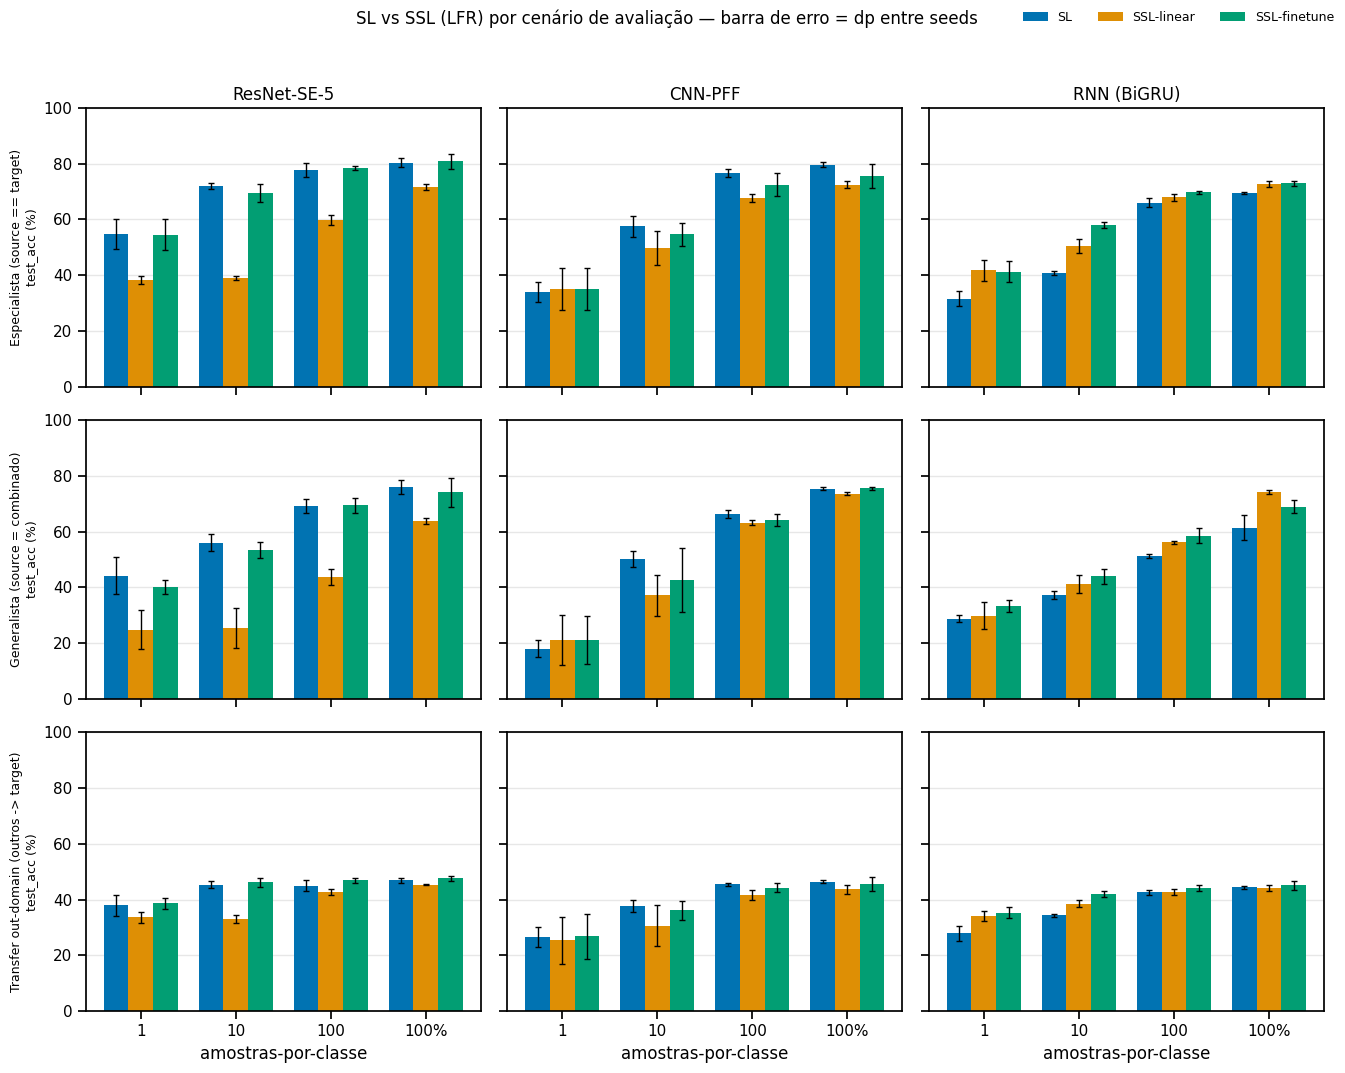

In [7]:
SCENARIOS = [
    ("esp",    "Especialista (source == target)"),
    ("comb",   "Generalista (source = combinado)"),
    ("transf", "Transfer out-domain (outros -> target)"),
]
SCENARIO_PRETTY = dict(SCENARIOS)

# Séries método: (rótulo, protocolo SSL ou None p/ o baseline SL)
METHOD_SERIES = [("SL", None), ("SSL-linear", "linear"), ("SSL-finetune", "finetune")]


def scenario_slice(df, scenario):
    """Filtra o DataFrame para um dos 3 cenários ('esp' | 'comb' | 'transf')."""
    if df.empty or "source" not in df.columns:
        return df
    if scenario == "esp":
        return df[df.source == df.target]
    if scenario == "comb":
        return df[df.source == COMBINED]
    return df[(df.source.isin(DATASETS)) & (df.source != df.target)]


def _method_df(key, proto, encoder=None):
    d = sup_df if proto is None else ssl_df[ssl_df.protocol == proto]
    if encoder is not None:
        d = d[d.encoder == encoder]
    return d


def bars_by_scenario(metric="test_acc"):
    if ssl_df.empty or sup_df.empty:
        print("Precisa dos dois caches (SSL e SL)."); return
    fig, axes = plt.subplots(3, 3, figsize=(13.5, 10.5), sharex=True, sharey=True)
    width = 0.26
    x = np.arange(len(SHOT_ORDER))
    for r, (scen, scen_title) in enumerate(SCENARIOS):
        for c, encoder in enumerate(ENCODERS):
            ax = axes[r, c]
            for k, (key, proto) in enumerate(METHOD_SERIES):
                d = scenario_slice(_method_df(key, proto, encoder), scen)
                means = [d[d.n_shots == s][metric].mean() * 100 for s in SHOT_ORDER]
                stds = [d[d.n_shots == s].groupby("seed")[metric].mean().std() * 100
                        for s in SHOT_ORDER]
                ax.bar(x + (k - 1) * width, means, width, yerr=stds, capsize=2,
                       color=METHOD_COLORS[key], error_kw={"elinewidth": 1},
                       label=key if (r == 0 and c == 0) else None)
            if r == 0:
                ax.set_title(ENCODER_PRETTY[encoder])
            if c == 0:
                ax.set_ylabel(f"{scen_title}\n{metric} (%)", fontsize=9)
            if r == 2:
                ax.set_xlabel("amostras-por-classe")
            ax.set_xticks(x); ax.set_xticklabels([SHOT_LABELS[s] for s in SHOT_ORDER])
            ax.set_ylim(0, 100); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
    fig.legend(loc="upper right", ncols=3, fontsize=9, frameon=False)
    fig.suptitle("SL vs SSL (LFR) por cenário de avaliação — barra de erro = dp entre seeds",
                 y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()


bars_by_scenario()

## 7. Δ(SSL − SL) caso a caso, por dataset

Barras divergentes do delta em **pontos percentuais** (positivo = SSL melhor),
um painel por encoder, barras agrupadas por regime. Responde *onde* o
pré-treino ajuda/atrapalha, dataset a dataset — a média agregada esconde sinais
opostos (ex.: CNN-PFF @KuHar vs @UCI).

- **Especialista + finetune**: o caso principal do experimento.
- **Especialista + linear**: mostra a separabilidade linear das features congeladas.
- **Combinado + finetune**: o generalista pré-treinado ajuda em quais alvos?

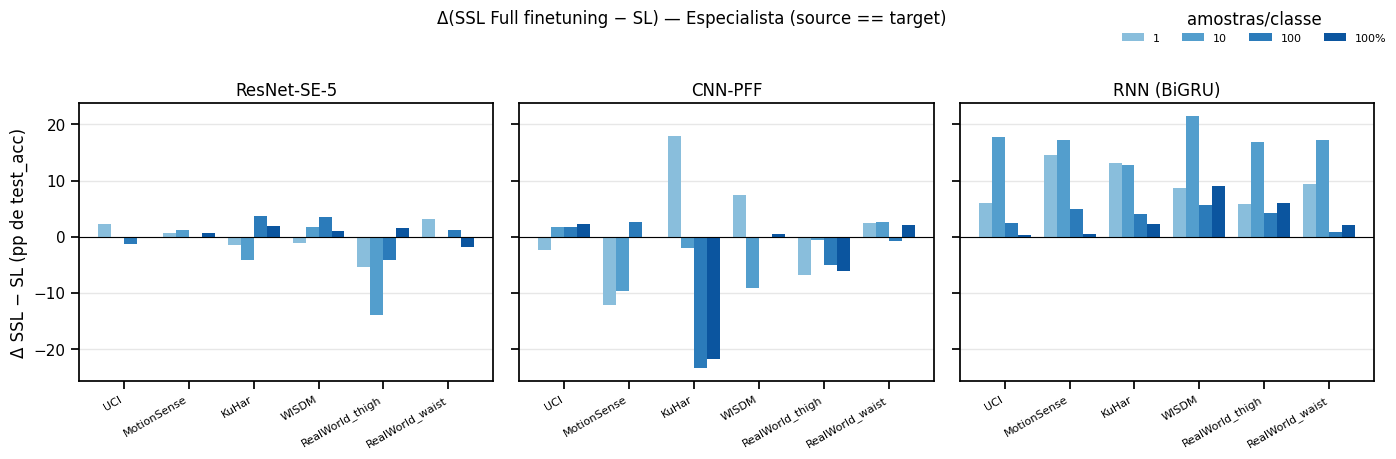

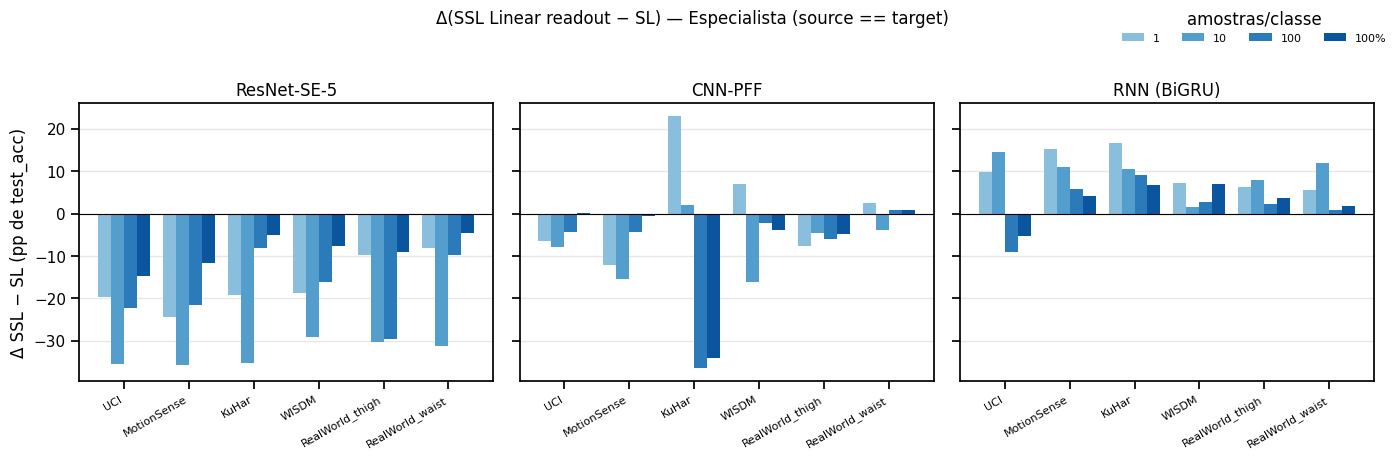

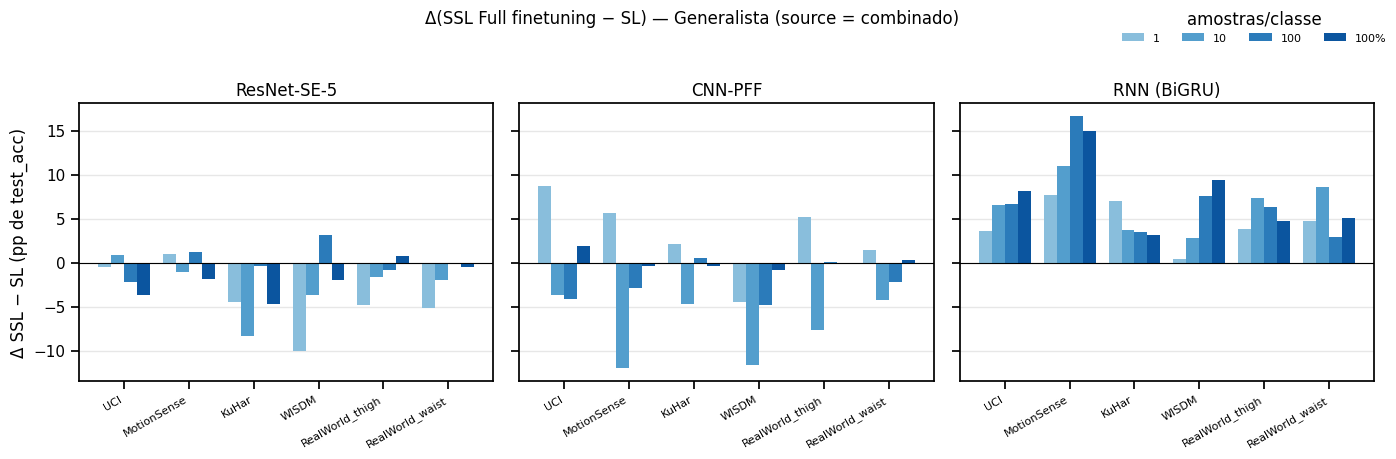

In [8]:
SHOT_BAR_COLORS = sns.color_palette("Blues", n_colors=len(SHOT_ORDER) + 2)[2:]


def delta_bars_by_dataset(scenario="esp", protocol="finetune", metric="test_acc"):
    """Δ(SSL[protocol] − SL) por dataset-alvo × regime, painéis por encoder."""
    if ssl_df.empty or sup_df.empty:
        print("Precisa dos dois caches (SSL e SL)."); return
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
    width = 0.2
    x = np.arange(len(DATASETS))
    for c, encoder in enumerate(ENCODERS):
        ax = axes[c]
        sl = scenario_slice(_method_df("SL", None, encoder), scenario)
        ss = scenario_slice(_method_df("SSL", protocol, encoder), scenario)
        for k, s in enumerate(SHOT_ORDER):
            deltas = []
            for t in DATASETS:
                sl_v = sl[(sl.target == t) & (sl.n_shots == s)][metric].mean()
                ss_v = ss[(ss.target == t) & (ss.n_shots == s)][metric].mean()
                deltas.append((ss_v - sl_v) * 100)
            ax.bar(x + (k - 1.5) * width, deltas, width, color=SHOT_BAR_COLORS[k],
                   label=SHOT_LABELS[s] if c == 0 else None)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(ENCODER_PRETTY[encoder])
        ax.set_xticks(x); ax.set_xticklabels(DATASETS, rotation=30, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
        if c == 0:
            ax.set_ylabel(f"Δ SSL − SL (pp de {metric})")
    fig.legend(title="amostras/classe", loc="upper right", ncols=4, fontsize=8, frameon=False)
    fig.suptitle(f"Δ(SSL {PROTOCOL_PRETTY[protocol]} − SL) — {SCENARIO_PRETTY[scenario]}",
                 y=1.04, fontsize=12)
    plt.tight_layout(); plt.show()


delta_bars_by_dataset("esp", "finetune")
delta_bars_by_dataset("esp", "linear")
delta_bars_by_dataset("comb", "finetune")

## 8. Transfer out-domain caso a caso — Δ(SSL − SL) fonte × alvo

Heatmaps divergentes do delta em pp por **par (fonte, alvo)** — azul = SSL
melhor, vermelho = SL melhor; diagonal (in-domain) mascarada. Mostra se o ganho
do SSL no transfer é uniforme ou concentrado em pares específicos de domínios.

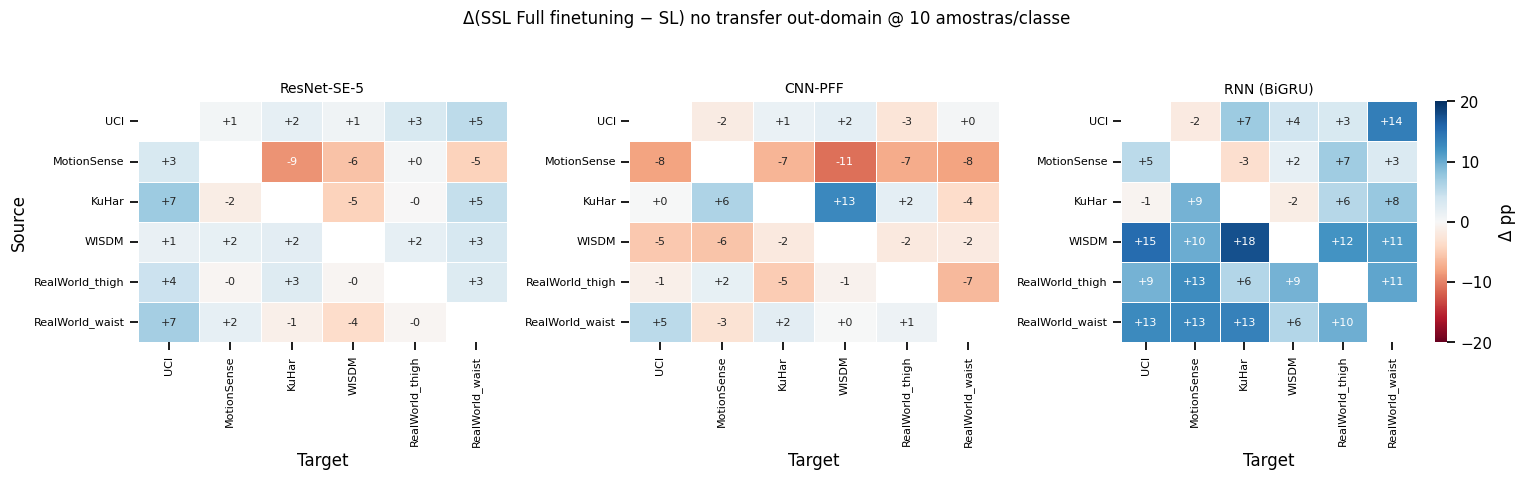

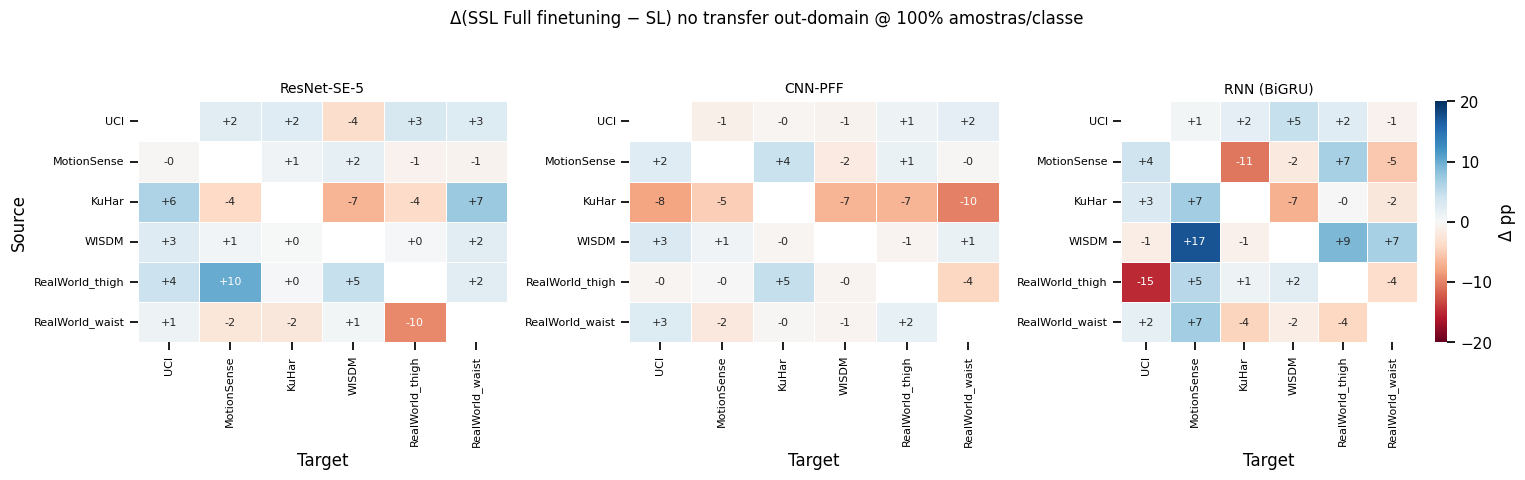

In [9]:
def delta_transfer_heatmap(protocol="finetune", n_shots="10", metric="test_acc", vmax=20):
    if ssl_df.empty or sup_df.empty:
        print("Precisa dos dois caches (SSL e SL)."); return
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
    mask = np.eye(len(DATASETS), dtype=bool)
    for c, encoder in enumerate(ENCODERS):
        ax = axes[c]
        def _mat(df):
            d = df[(df.encoder == encoder) & (df.n_shots == n_shots)
                   & (df.source.isin(DATASETS))]
            return (d.groupby(["source", "target"])[metric].mean()
                    .unstack().reindex(index=DATASETS, columns=DATASETS))
        delta = (_mat(ssl_df[ssl_df.protocol == protocol]) - _mat(sup_df)) * 100
        sns.heatmap(delta, annot=True, fmt="+.0f", cmap="RdBu", center=0,
                    vmin=-vmax, vmax=vmax, mask=mask, ax=ax, linewidths=0.5,
                    cbar=(c == 2), cbar_kws={"label": "Δ pp"},
                    annot_kws={"fontsize": 8})
        ax.set_title(ENCODER_PRETTY[encoder], fontsize=10)
        ax.set_xlabel("Target"); ax.set_ylabel("Source" if c == 0 else "")
        ax.tick_params(labelsize=8)
    fig.suptitle(f"Δ(SSL {PROTOCOL_PRETTY[protocol]} − SL) no transfer out-domain "
                 f"@ {SHOT_LABELS.get(n_shots, n_shots)} amostras/classe", y=1.04, fontsize=12)
    plt.tight_layout(); plt.show()


delta_transfer_heatmap("finetune", "10")
delta_transfer_heatmap("finetune", "full")

## 9. Especialista × Combinado × Transfer, por alvo

Para cada dataset-alvo: quanto rende o modelo **especialista** (treinado no
próprio alvo), o **generalista** (combinado) e o **transfer** médio (média dos
outros 5 como fonte)? Linha de cima = SL do zero; linha de baixo = SSL finetune.
Comparar as duas linhas mostra se o pré-treino muda o *gap* de generalização —
relevante para o cenário federado, onde nenhum cliente tem o "especialista"
dos demais domínios.

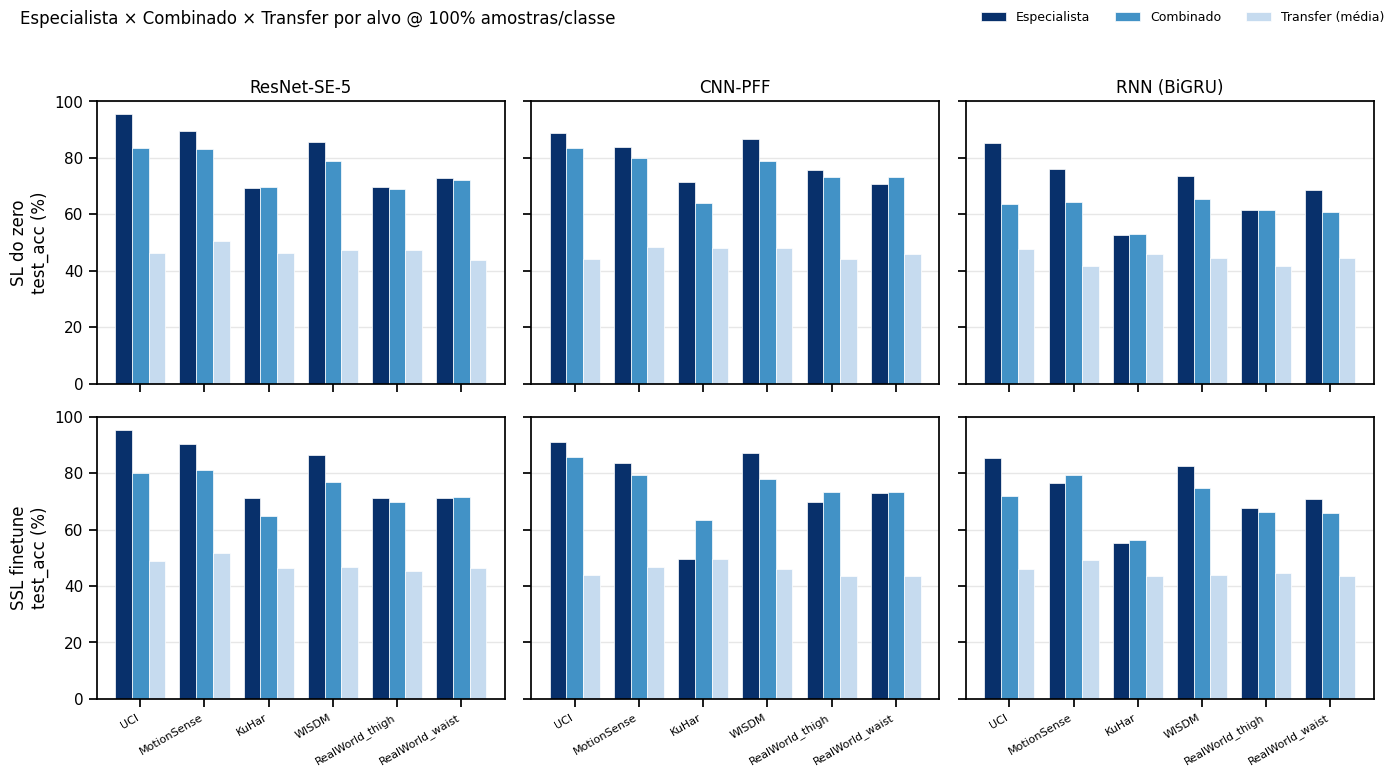

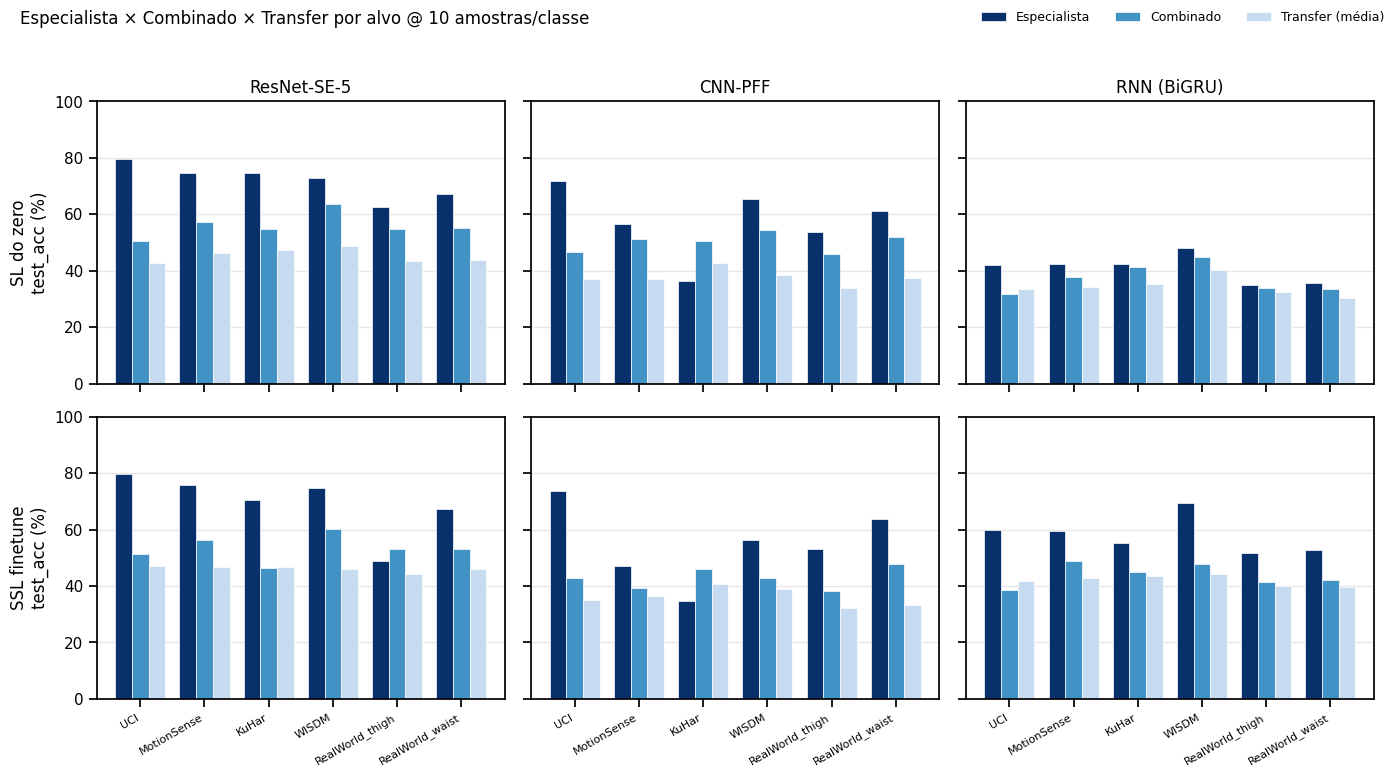

In [10]:
FONTE_TIPO_COLORS = {"esp": "#08306b", "comb": "#4292c6", "transf": "#c6dbef"}
FONTE_TIPO_PRETTY = {"esp": "Especialista", "comb": "Combinado", "transf": "Transfer (média)"}


def gap_bars(n_shots="full", metric="test_acc"):
    if ssl_df.empty or sup_df.empty:
        print("Precisa dos dois caches (SSL e SL)."); return
    rows = [("SL do zero", None), ("SSL finetune", "finetune")]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7.6), sharex=True, sharey=True)
    width = 0.26
    x = np.arange(len(DATASETS))
    for r, (row_label, proto) in enumerate(rows):
        for c, encoder in enumerate(ENCODERS):
            ax = axes[r, c]
            base = _method_df(row_label, proto, encoder)
            base = base[base.n_shots == n_shots]
            for k, scen in enumerate(["esp", "comb", "transf"]):
                d = scenario_slice(base, scen)
                vals = [d[d.target == t][metric].mean() * 100 for t in DATASETS]
                ax.bar(x + (k - 1) * width, vals, width, color=FONTE_TIPO_COLORS[scen],
                       edgecolor="white", linewidth=0.5,
                       label=FONTE_TIPO_PRETTY[scen] if (r == 0 and c == 0) else None)
            if r == 0:
                ax.set_title(ENCODER_PRETTY[encoder])
            if c == 0:
                ax.set_ylabel(f"{row_label}\n{metric} (%)")
            if r == 1:
                ax.set_xticks(x); ax.set_xticklabels(DATASETS, rotation=30, ha="right", fontsize=8)
            ax.set_ylim(0, 100); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
    fig.legend(loc="upper right", ncols=3, fontsize=9, frameon=False)
    fig.suptitle(f"Especialista × Combinado × Transfer por alvo @ "
                 f"{SHOT_LABELS.get(n_shots, n_shots)} amostras/classe",
                 x=0.02, y=1.02, ha="left", fontsize=12)
    plt.tight_layout(); plt.show()


gap_bars("full")
gap_bars("10")

### 9.1 A inversão Especialista ↔ Combinado

**Hipótese**: no SL a ordem Transfer < Combinado < Especialista é clara; com
pré-treino ela inverteria em alguns casos (acc Especialista < acc Combinado).
Três visões: (i) Δ(Combinado − Especialista) célula a célula; (ii) dispersão
Especialista × Combinado (acima da diagonal = inversão); (iii) os dois casos
notáveis, seed a seed. **Nota**: em 1/10/100-shot o orçamento de rótulos é o
mesmo nos dois cenários (k por classe *no total*); só @100% o combinado tem
~6× mais rótulos — e o contraste com o SL (mesma vantagem, sem inversão) é o
que isola o papel do pré-treino.

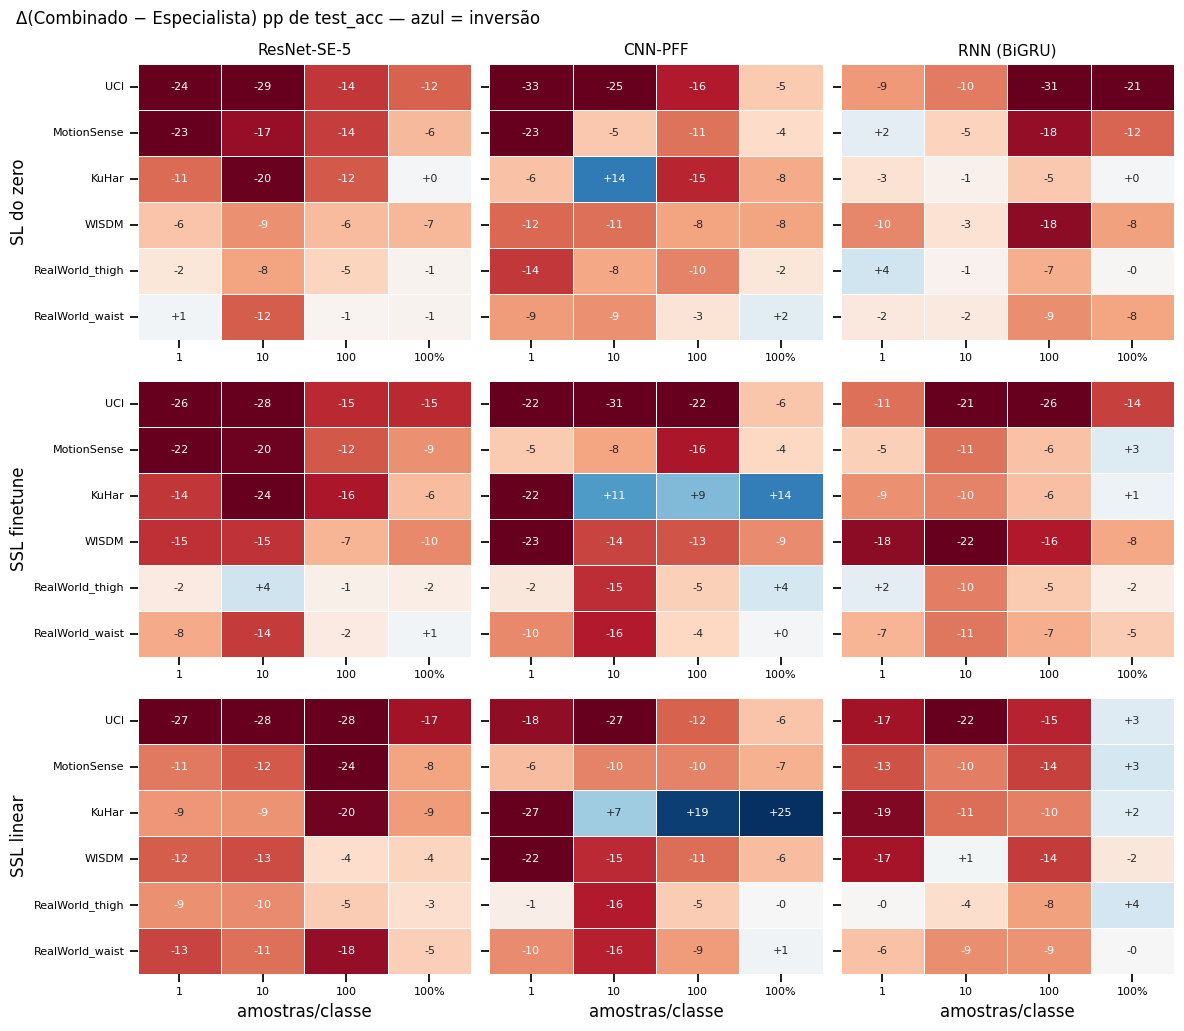

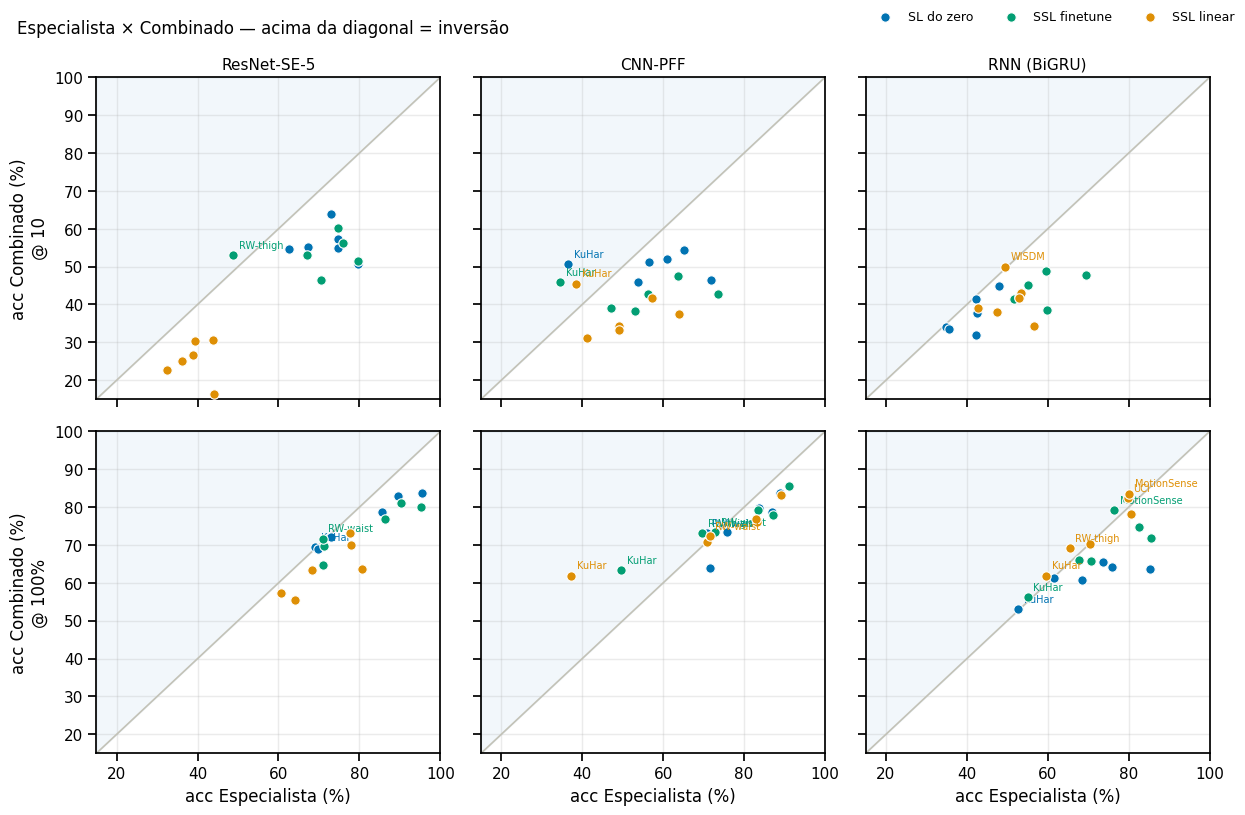

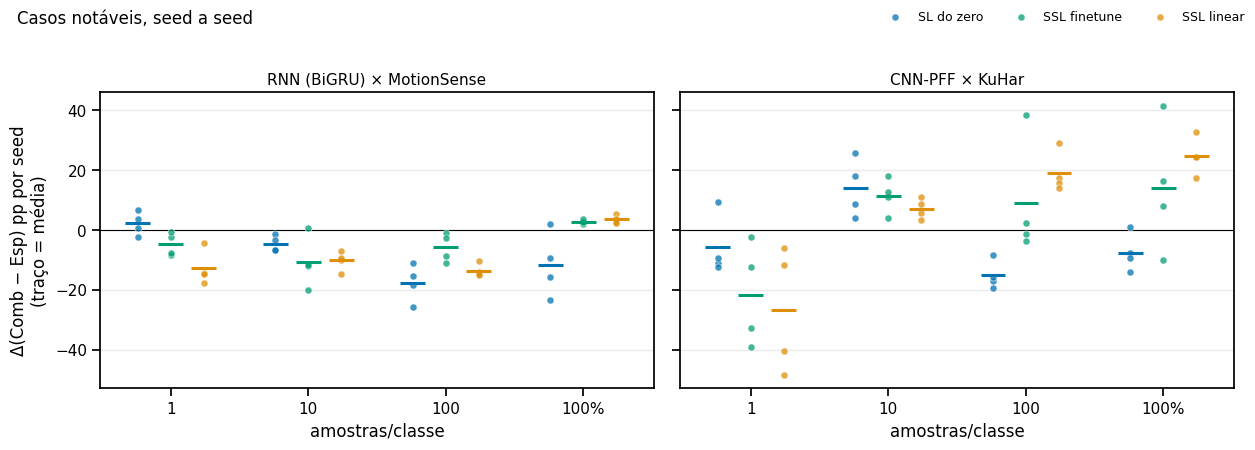

In [11]:
HYP_METHODS = [("SL", None), ("SSL-finetune", "finetune"), ("SSL-linear", "linear")]
HYP_METHOD_LBL = {"SL": "SL do zero", "SSL-finetune": "SSL finetune", "SSL-linear": "SSL linear"}


def _scen_acc(proto, encoder, scen, target, shots, per_seed=False):
    """acc média (ou vetor por seed) de um método num cenário/alvo/regime."""
    d = scenario_slice(_method_df("", proto, encoder), scen)
    d = d[(d.target == target) & (d.n_shots == shots)]
    return d.sort_values("seed").test_acc.values if per_seed else d.test_acc.mean()


def hyp_inversion_heatmap(metric_scale=100):
    fig, axes = plt.subplots(3, 3, figsize=(12, 10.5))
    for r, (key, proto) in enumerate(HYP_METHODS):
        for c, encoder in enumerate(ENCODERS):
            ax = axes[r, c]
            mat = pd.DataFrame(
                [[metric_scale * (_scen_acc(proto, encoder, "comb", t, s)
                                  - _scen_acc(proto, encoder, "esp", t, s))
                  for s in SHOT_ORDER] for t in DATASETS],
                index=DATASETS, columns=[SHOT_LABELS[s] for s in SHOT_ORDER])
            sns.heatmap(mat, annot=True, fmt="+.0f", cmap="RdBu", center=0,
                        vmin=-20, vmax=20, ax=ax, linewidths=0.5, cbar=False,
                        annot_kws={"fontsize": 8})
            if r == 0:
                ax.set_title(ENCODER_PRETTY[encoder], fontsize=11)
            ax.set_ylabel(HYP_METHOD_LBL[key] if c == 0 else "")
            ax.set_yticklabels(ax.get_yticklabels() if c == 0 else [], fontsize=8, rotation=0)
            ax.set_xlabel("amostras/classe" if r == 2 else "")
            ax.tick_params(labelsize=8)
    fig.suptitle("Δ(Combinado − Especialista) pp de test_acc — azul = inversão",
                 x=0.02, ha="left", fontsize=12)
    plt.tight_layout(); plt.show()


def hyp_scatter(shots_rows=("10", "full")):
    fig, axes = plt.subplots(len(shots_rows), 3, figsize=(12.5, 4.1 * len(shots_rows)),
                             sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    for r, s in enumerate(shots_rows):
        for c, encoder in enumerate(ENCODERS):
            ax = axes[r, c]
            lim = (15, 100)
            ax.plot(lim, lim, color="#c3c2b7", linewidth=1.2, zorder=1)
            ax.fill_between(lim, lim, lim[1], color="#0173B2", alpha=0.05, zorder=0)
            for key, proto in HYP_METHODS:
                color = METHOD_COLORS[key if key != "SL" else "SL"]
                xs = [100 * _scen_acc(proto, encoder, "esp", t, s) for t in DATASETS]
                ys = [100 * _scen_acc(proto, encoder, "comb", t, s) for t in DATASETS]
                ax.scatter(xs, ys, s=46, color=color, zorder=3, edgecolors="white",
                           linewidths=0.8, label=HYP_METHOD_LBL[key] if (r == 0 and c == 0) else None)
                for x, y, t in zip(xs, ys, DATASETS):
                    if y > x:
                        ax.annotate(t.replace("RealWorld_", "RW-"), (x, y), xytext=(4, 5),
                                    textcoords="offset points", fontsize=7, color=color)
            ax.set_xlim(lim); ax.set_ylim(lim)
            ax.grid(alpha=0.25); ax.set_axisbelow(True)
            if r == 0:
                ax.set_title(ENCODER_PRETTY[encoder], fontsize=11)
            if c == 0:
                ax.set_ylabel(f"acc Combinado (%)\n@ {SHOT_LABELS[s]}")
            if r == len(shots_rows) - 1:
                ax.set_xlabel("acc Especialista (%)")
    fig.legend(loc="upper right", ncols=3, fontsize=9, frameon=False)
    fig.suptitle("Especialista × Combinado — acima da diagonal = inversão",
                 x=0.02, ha="left", fontsize=12)
    plt.tight_layout(); plt.show()


def hyp_seed_cases(cases=(("rnn", "MotionSense"), ("cnnpff", "KuHar"))):
    fig, axes = plt.subplots(1, len(cases), figsize=(6.3 * len(cases), 4.4), sharey=True)
    x = np.arange(len(SHOT_ORDER))
    for ax, (encoder, target) in zip(np.atleast_1d(axes), cases):
        for k, (key, proto) in enumerate(HYP_METHODS):
            color = METHOD_COLORS[key]
            for i, s in enumerate(SHOT_ORDER):
                dv = 100 * (_scen_acc(proto, encoder, "comb", target, s, per_seed=True)
                            - _scen_acc(proto, encoder, "esp", target, s, per_seed=True))
                xj = x[i] + (k - 1) * 0.24
                ax.scatter([xj] * len(dv), dv, s=26, color=color, alpha=0.75,
                           edgecolors="white", linewidths=0.5, zorder=3,
                           label=HYP_METHOD_LBL[key] if (i == 0 and encoder == cases[0][0]) else None)
                ax.hlines(dv.mean(), xj - 0.09, xj + 0.09, color=color, linewidth=2.2, zorder=4)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xticks(x); ax.set_xticklabels([SHOT_LABELS[s] for s in SHOT_ORDER])
        ax.set_xlabel("amostras/classe")
        ax.set_title(f"{ENCODER_PRETTY[encoder]} × {target}", fontsize=11)
        ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
    np.atleast_1d(axes)[0].set_ylabel("Δ(Comb − Esp) pp por seed\n(traço = média)")
    fig.legend(loc="upper right", ncols=3, fontsize=9, frameon=False)
    fig.suptitle("Casos notáveis, seed a seed", x=0.02, ha="left", y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()


hyp_inversion_heatmap()
hyp_scatter()
hyp_seed_cases()

### 9.2 Isolando o mecanismo: pré-treino no combinado + finetune só no alvo

O cenário "Combinado" mistura dois fatores: corpus de **pré-treino** (6 domínios)
e dados rotulados de **finetune** (6 domínios). O experimento *comb→target*
(`scripts/ssl/run_comb2target.py`) separa-os: backbone pré-treinado no
`combined` + refinamento só no train do alvo (protocolo idêntico ao
especialista). Decomposição, por célula:

    Δ(comb − esp) = Δ(comb→t − esp)      [efeito do corpus de pré-treino]
                  + Δ(comb − comb→t)     [efeito dos dados rotulados combinados]

Se `comb→t ≥ esp`, a diversidade de pré-treino sozinha já não custa nada ao
domínio-alvo — o resultado relevante para o pré-treino SSL **federado** (Exp. 3).

Cada célula é o *proxy centralizado* de uma implantação federada (decisão de
2026-07-06: **`comb` e `comb→t` são co-principais** na avaliação, cada uma com
seu contrafactual):

| Célula | Pré-treino | Finetune | Implantação federada correspondente |
|---|---|---|---|
| `esp` | target | target | sem federação (contrafactual local) |
| `comb` | combinado | combinado | modelo global único (pré-treino + finetuning federados) |
| `comb→t` | combinado | target | backbone global + **personalização local** |

comb→target: 3456 linhas | fontes(finetune)=['KuHar', 'MotionSense', 'RealWorld_thigh', 'RealWorld_waist', 'UCI', 'WISDM']


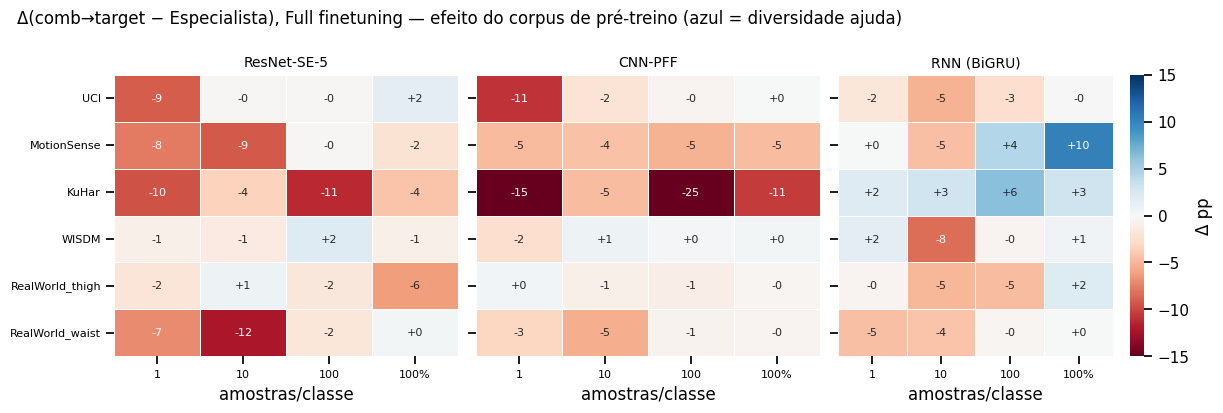

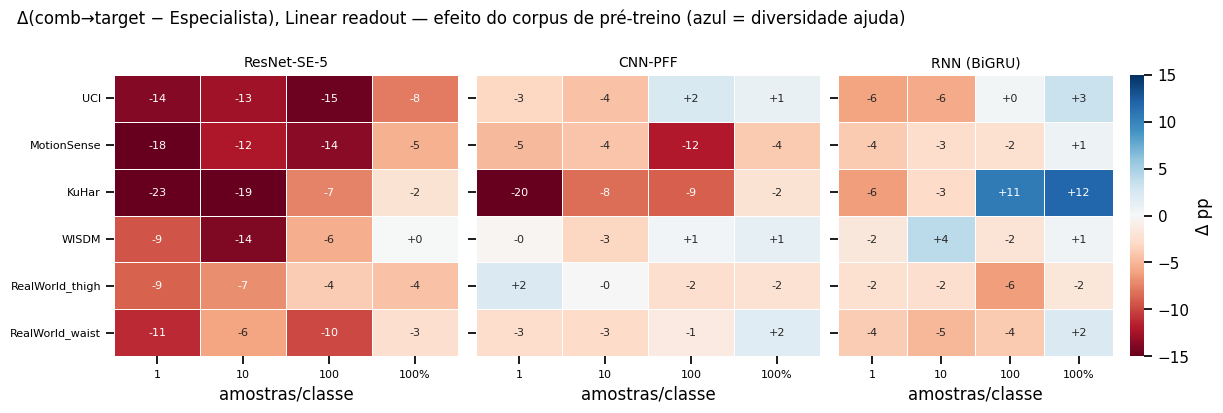

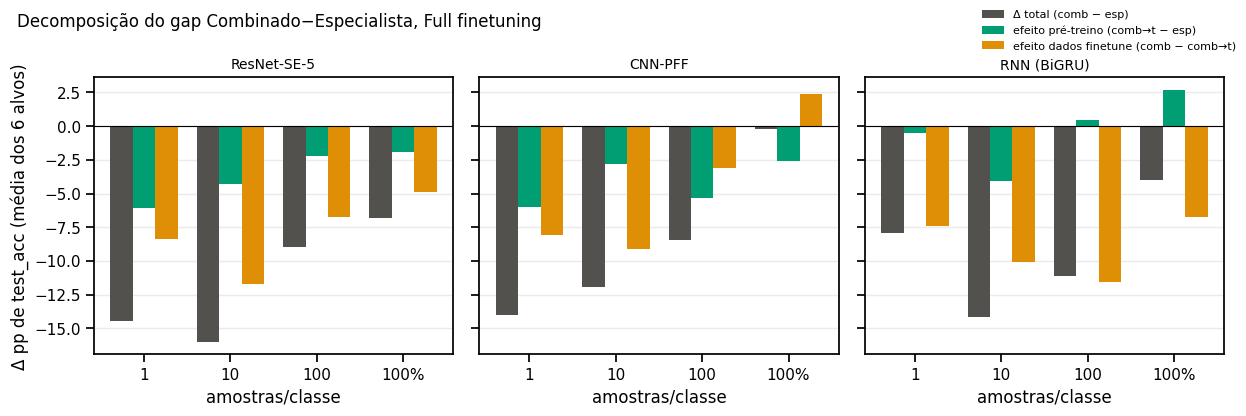

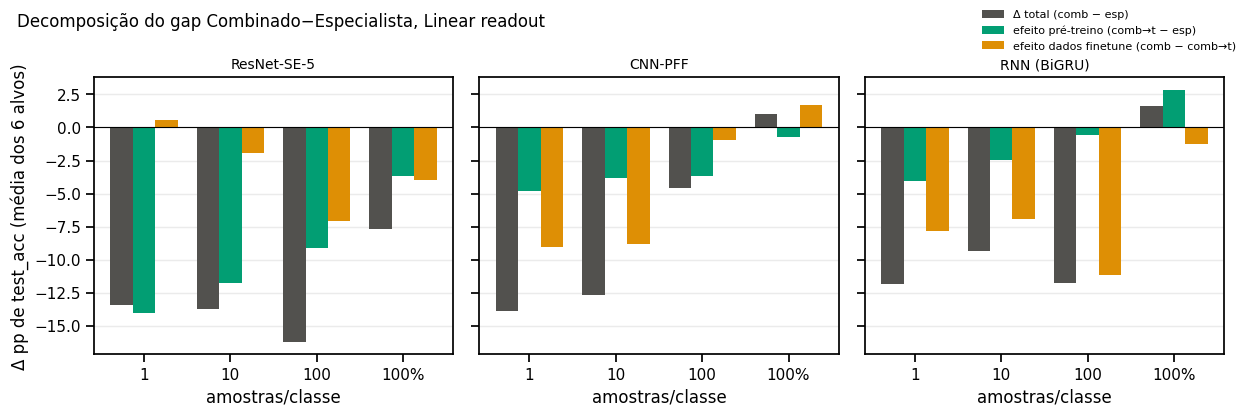

In [12]:
C2T_CACHE = RESULTS_DIR / "ssl_lfr_comb2target_eval_transfer.csv"
c2t_df = _load(C2T_CACHE, SSL_COLS)
if not c2t_df.empty:
    print(f"comb→target: {len(c2t_df)} linhas | fontes(finetune)={sorted(c2t_df.source.unique())}")


def _c2t_acc(proto, encoder, target, shots, per_seed=False):
    """acc in-domain do comb→target (finetune no alvo, backbone do combined)."""
    d = c2t_df[(c2t_df.protocol == proto) & (c2t_df.encoder == encoder)
               & (c2t_df.source == target) & (c2t_df.target == target)
               & (c2t_df.n_shots == shots)]
    return d.sort_values("seed").test_acc.values if per_seed else d.test_acc.mean()


def c2t_heatmap(protocol="finetune"):
    """Δ(comb→t − esp): efeito do corpus de pré-treino, mesmos dados de finetune."""
    if c2t_df.empty:
        print("Cache comb→target ausente — rode scripts/ssl/run_comb2target.py."); return
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2))
    for c, encoder in enumerate(ENCODERS):
        ax = axes[c]
        mat = pd.DataFrame(
            [[100 * (_c2t_acc(protocol, encoder, t, s)
                     - _scen_acc(protocol, encoder, "esp", t, s)) for s in SHOT_ORDER]
             for t in DATASETS],
            index=DATASETS, columns=[SHOT_LABELS[s] for s in SHOT_ORDER])
        sns.heatmap(mat, annot=True, fmt="+.0f", cmap="RdBu", center=0, vmin=-15, vmax=15,
                    ax=ax, linewidths=0.5, cbar=(c == 2), cbar_kws={"label": "Δ pp"},
                    annot_kws={"fontsize": 8})
        ax.set_title(ENCODER_PRETTY[encoder], fontsize=10)
        ax.set_yticklabels(ax.get_yticklabels() if c == 0 else [], fontsize=8, rotation=0)
        ax.set_xlabel("amostras/classe"); ax.tick_params(labelsize=8)
    fig.suptitle(f"Δ(comb→target − Especialista), {PROTOCOL_PRETTY[protocol]} — "
                 "efeito do corpus de pré-treino (azul = diversidade ajuda)",
                 x=0.02, ha="left", fontsize=12)
    plt.tight_layout(); plt.show()


def c2t_decomposition(protocol="finetune"):
    """Barras: Δ total (comb−esp) decomposto em pré-treino vs dados de finetune."""
    if c2t_df.empty:
        print("Cache comb→target ausente — rode scripts/ssl/run_comb2target.py."); return
    comp_colors = {"total": "#52514E", "pretreino": "#029E73", "dados": "#DE8F05"}
    comp_lbl = {"total": "Δ total (comb − esp)", "pretreino": "efeito pré-treino (comb→t − esp)",
                "dados": "efeito dados finetune (comb − comb→t)"}
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2), sharey=True)
    x = np.arange(len(SHOT_ORDER))
    for c, encoder in enumerate(ENCODERS):
        ax = axes[c]
        for k, comp in enumerate(["total", "pretreino", "dados"]):
            vals = []
            for s in SHOT_ORDER:
                esp = np.mean([_scen_acc(protocol, encoder, "esp", t, s) for t in DATASETS])
                comb = np.mean([_scen_acc(protocol, encoder, "comb", t, s) for t in DATASETS])
                c2t = np.mean([_c2t_acc(protocol, encoder, t, s) for t in DATASETS])
                delta = {"total": comb - esp, "pretreino": c2t - esp, "dados": comb - c2t}[comp]
                vals.append(100 * delta)
            ax.bar(x + (k - 1) * 0.26, vals, 0.26, color=comp_colors[comp],
                   label=comp_lbl[comp] if c == 0 else None)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xticks(x); ax.set_xticklabels([SHOT_LABELS[s] for s in SHOT_ORDER])
        ax.set_title(ENCODER_PRETTY[encoder], fontsize=10)
        ax.set_xlabel("amostras/classe")
        ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
        if c == 0:
            ax.set_ylabel("Δ pp de test_acc (média dos 6 alvos)")
    fig.legend(loc="upper right", ncols=1, fontsize=8, frameon=False)
    fig.suptitle(f"Decomposição do gap Combinado−Especialista, {PROTOCOL_PRETTY[protocol]}",
                 x=0.02, ha="left", fontsize=12)
    plt.tight_layout(); plt.show()


c2t_heatmap("finetune")
c2t_heatmap("linear")
c2t_decomposition("finetune")
c2t_decomposition("linear")

## 10. Conclusões

*Grade v1 (config oficial do benchmark), validada contra o paper em 2026-07-06 —
viés −1.2..+1.8 pp e desvio absoluto médio 2.1–4.6 pp de acurácia vs o
`performance_data.json` oficial (ver Seção 9 das notas internas).*

- **Eficiência de dados**: o ganho grande e consistente do LFR é **só da RNN**
  (+7 a +9 pp de F1 na matriz completa em 1/10-shot; até +21 pp in-domain,
  positivo em todos os 6 datasets). ResNet-SE-5 fica ~neutro no finetune
  (+0.3 a +2.3 pp) e CNN-PFF é misto (ajuda @1-shot, atrapalha de 10-shot em
  diante). **O paper reporta o mesmo padrão** (+18.1 / +1.5 / +0.1 pp @10-shot,
  respectivamente).
- **Teto a 100%**: `SSL finetune @ full` ≈ SL na diagonal para os 3 encoders
  (RNN levemente acima, +1.9 pp).
- **Linear vs finetune**: o readout linear só compete na RNN. Na ResNet-SE-5 é
  fraco por natureza do método (nós: −20 pp @10-shot; paper: −32 pp) — achado
  replicado, não bug.
- **Transferência**: o domain shift domina o transfer out-domain (acc na faixa
  de 20–40%) para todos os métodos; o SSL não fecha esse gap, só desloca o
  nível (RNN) — motivação intacta para a parte federada.
- **Inversão Especialista↔Combinado (§9.1–9.2)**: em few-shot a ordem
  Transfer < Comb < Esp vale em SL e SSL; @100% a inversão aparece e é
  específica do SSL (SSL-linear RNN: 4/6 alvos, Δ médio +1.6 pp;
  RNN×MotionSense 4/4 seeds) — o SL não inverte nem com ~6× rótulos no
  combinado.
- **Mecanismo (comb→target, §9.2)**: a decomposição mostra que o custo do
  cenário combinado vem majoritariamente dos **dados rotulados mistos no
  finetune**, não do pré-treino. O efeito isolado do corpus de pré-treino
  multi-domínio é ~0 ou **positivo** para a RNN @100% (comb→t ≥ esp em 5/6
  alvos nos 2 protocolos; MotionSense: 76.5% → **86.8%**, +10.3 pp, 4/4
  seeds — backbone global + finetune local supera o especialista E o modelo
  global). Para o federado: pré-treino federado + personalização local é a
  configuração mais promissora observada.

Próximos passos do plano (Seção 10 das notas internas): encoder **TS-TCC**
(supervisionado, LFR e federado), **TF-C** nos 4 encoders (reusa
`downstream_eval.py`), e o **Experimento 2** (SSL centralizado → finetuning
federado), plugando estes backbones no `scripts/federated/`.